In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"liharika91","key":"476b309a1cc7c6d7a6c133682cb35f02"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d rm1000/lung-cancer-histopathological-images

Dataset URL: https://www.kaggle.com/datasets/rm1000/lung-cancer-histopathological-images
License(s): CC-BY-SA-4.0


In [ ]:
!unzip lung-cancer-histopathological-images.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/squamous_cell_carcinoma/0000.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0001.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0002.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0003.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0004.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0005.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0006.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0007.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0008.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0009.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0010.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0011.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0012.jpg  
  inflating: /content/dataset/squamous_cell_carcinoma/0013.jpg  
  inflating: /content/dataset/squamous_

In [ ]:
!ls /content/dataset

adenocarcinoma	benign	squamous_cell_carcinoma


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

dataset_dir = '/content/dataset'
output_dir = '/content/split_dataset1'

class_names = ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

os.makedirs(os.path.join(output_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'val'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'test'), exist_ok=True)

for class_name in class_names:
    os.makedirs(os.path.join(output_dir, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val', class_name), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'test', class_name), exist_ok=True)

    class_dir = os.path.join(dataset_dir, class_name)
    images = os.listdir(class_dir)
    images = [img for img in images if img.endswith(('.jpg', '.png', '.jpeg'))]

    train_images, test_images = train_test_split(images, test_size=1 - train_ratio, random_state=42)
    val_images, test_images = train_test_split(test_images, test_size=test_ratio/(test_ratio + val_ratio), random_state=42)

    for img in train_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(output_dir, 'train', class_name, img)
        shutil.copy(src, dst)

    for img in val_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(output_dir, 'val', class_name, img)
        shutil.copy(src, dst)

    for img in test_images:
        src = os.path.join(class_dir, img)
        dst = os.path.join(output_dir, 'test', class_name, img)
        shutil.copy(src, dst)

    print(f"Class: {class_name}")
    print(f"  Training images: {len(train_images)}")
    print(f"  Validation images: {len(val_images)}")
    print(f"  Test images: {len(test_images)}")
    print()

print("Dataset splitting completed!")

Class: adenocarcinoma
  Training images: 3499
  Validation images: 750
  Test images: 751

Class: benign
  Training images: 3499
  Validation images: 750
  Test images: 751

Class: squamous_cell_carcinoma
  Training images: 3499
  Validation images: 750
  Test images: 751

Dataset splitting completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
import os
from sklearn.metrics import classification_report

In [ ]:

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dir = '/content/split_dataset1/train'
val_dir = '/content/split_dataset1/val'
test_dir = '/content/split_dataset1/test'

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training dataset size: 10497
Validation dataset size: 2250
Test dataset size: 2253
Classes: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']


In [ ]:

model = create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    return train_loss, train_acc

def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Epoch 1/10
Train Loss: 0.1581, Train Acc: 93.60%
Val Loss: 0.0755, Val Acc: 96.98%
Epoch 2/10
Train Loss: 0.0713, Train Acc: 97.30%
Val Loss: 0.0084, Val Acc: 99.73%
Epoch 3/10
Train Loss: 0.0588, Train Acc: 97.91%
Val Loss: 0.0086, Val Acc: 99.64%
Epoch 4/10
Train Loss: 0.0552, Train Acc: 98.18%
Val Loss: 0.0047, Val Acc: 99.91%
Epoch 5/10
Train Loss: 0.0389, Train Acc: 98.50%
Val Loss: 0.0048, Val Acc: 99.82%
Epoch 6/10
Train Loss: 0.0396, Train Acc: 98.60%
Val Loss: 0.0076, Val Acc: 99.69%
Epoch 7/10
Train Loss: 0.0328, Train Acc: 98.86%
Val Loss: 0.0263, Val Acc: 99.11%
Epoch 8/10
Train Loss: 0.0386, Train Acc: 98.74%
Val Loss: 0.0014, Val Acc: 100.00%
Epoch 9/10
Train Loss: 0.0313, Train Acc: 98.83%
Val Loss: 0.0314, Val Acc: 98.98%
Epoch 10/10
Train Loss: 0.0383, Train Acc: 98.67%
Val Loss: 0.0018, Val Acc: 99.96%


In [ ]:
def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(test_loader)
    test_acc = 100. * correct / total

    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

test(model, test_loader, criterion, device)


Test Loss: 0.0011, Test Acc: 99.87%

              precision    recall    f1-score    support

lung_aca         0.998      0.997      0.997      751
lung_n           0.999      0.998      0.998      751
lung_scc         0.997      0.996      0.996      751

accuracy                               0.998      2253
macro avg        0.998      0.997      0.997      2253
weighted avg     0.998      0.997      0.997      2253



In [ ]:
torch.save(model.state_dict(), 'swin_transformer_lung_cancer.pth')

Confusion Matrix:
[[750   1   0]
 [  0 750   1]
 [  1   0 750]]


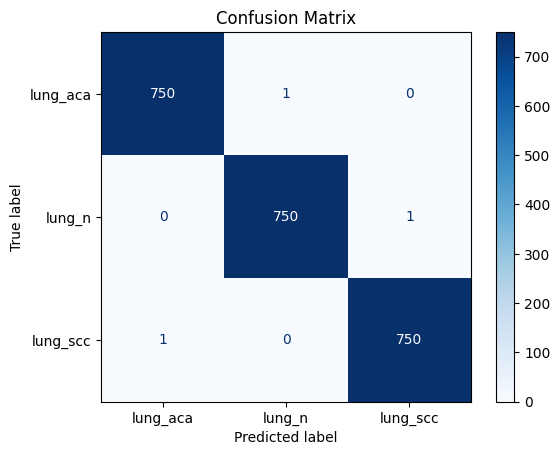

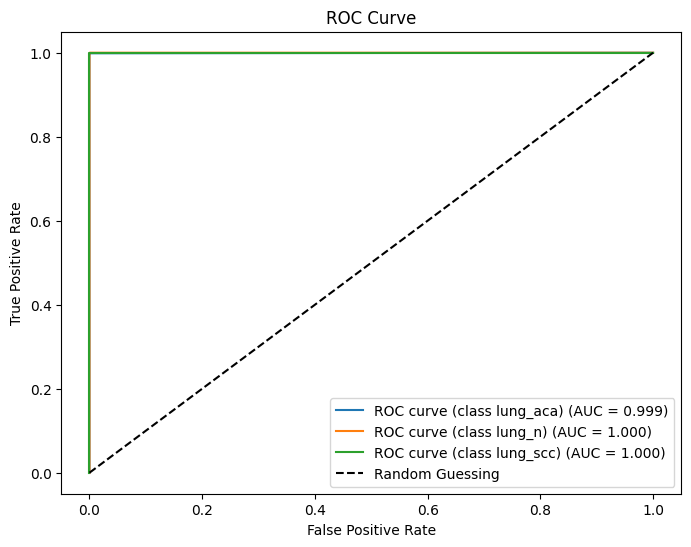

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

model.eval()
true_labels = []
predicted_labels = []
predicted_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)
predicted_probs = np.array(predicted_probs)

conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=train_dataset.classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(train_dataset.classes)):
    fpr[i], tpr[i], _ = roc_curve(true_labels, predicted_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(len(train_dataset.classes)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve (class {train_dataset.classes[i]}) (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

accuracy = np.mean(true_labels == predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

In [ ]:
from PIL import Image

def predict(image_path, model, transform, device):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, predicted = output.max(1)

    return train_dataset.classes[predicted.item()]

image_path = '/content/split_dataset1/test/adenocarcinoma/0021.jpg'
predicted_class = predict(image_path, model, val_test_transform, device)
print(f'Predicted Class: {predicted_class}')

Predicted Class: adenocarcinoma


In [ ]:
from google.colab import files
files.download('/content/swin_transformer_lung_cancer.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import timm
model = timm.create_model('swin_base_patch4_window7_224', pretrained=False, num_classes=3)

model_path = '/content/swin_transformer_lung_cancer.pth'
model.load_state_dict(torch.load(model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)
    return image

image_path = '/content/split_dataset1/test/adenocarcinoma/0289.jpg'
image = preprocess_image(image_path, transform)
image = image.to(device)

with torch.no_grad():
    output = model(image)
    probabilities = torch.softmax(output, dim=1)
    _, predicted_class = torch.max(probabilities, 1)

class_names = ['lung_aca', 'lung_n', 'lung_scc']
predicted_class_name = class_names[predicted_class.item()]

print(f"Predicted Class: {predicted_class_name}")
print(f"Class Probabilities: {probabilities.cpu().numpy()}")

Predicted Class: lung_aca
Class Probabilities: [[9.9997509e-01 1.8356213e-05 6.5959398e-06]]
